# Surrey Biome Pipeline — Phase 3 Walkthrough
### Modeling & hypothesis testing: does scale-free downscaling actually buy anything?

**Hypothesis.** Downscaled, scale-free ClimateBC predictors (~375–750 m) forecast
localized corridor water stress **better** than coarse grid-based climate, on the
same Surrey GIN corridors.

The test is deliberately narrow. Model A and Model B share the target, the
corridors, the summers, the algorithm, the feature list and the folds. The *only*
thing that differs is spatial resolution — Model B is Model A's own variables
averaged into coarse cells. Anything else would confound "which dataset" with
"what resolution".

This notebook runs the pipeline stage by stage and visualizes each one. It loads
cached artifacts from `data/`; set `REFETCH = True` to regenerate from source
(note: the ClimateBC acquisition is rate-limited to 50 calls/hour and takes many
hours — see Stage 1).

**Kernel:** *Surrey Biome (venv)*.

In [1]:
# --- setup: paths resolve from the installed package, not the cwd ---
# The project is installed editable (`uv pip install -e .`), so `src.pipeline`
# imports and `paths.*` point at this working tree from ANY directory — you can
# launch Jupyter from ~, /tmp, or anywhere else. The fallback below only fires
# if the package was never installed.
try:
    from src.pipeline import paths
except ModuleNotFoundError:  # not installed — walk up to find the repo root
    import sys
    from pathlib import Path
    here = Path.cwd().resolve()
    root = next((p for p in (here, *here.parents) if (p / "pyproject.toml").exists()), None)
    if root is None:
        raise RuntimeError(
            "Cannot locate the repo. Run `uv pip install -e .` from the project root."
        ) from None
    sys.path.insert(0, str(root))
    from src.pipeline import paths

import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import rioxarray

REPO, RAW, INT, PROC = paths.REPO, paths.RAW, paths.INTERIM, paths.PROCESSED
REFETCH = False           # True re-hits STAC / the ClimateBC API
YEARS = (2022, 2023, 2024, 2025)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})
print("repo root:", REPO, "| study summers:", YEARS)
print("launched from:", __import__("os").getcwd())


repo root: /path/to/surrey-biome-pipeline | study summers: (2022, 2023, 2024, 2025)
launched from: /path/to/surrey-biome-pipeline/notebooks


## Stage 1 — Predictors: scale-free ClimateBC

ClimateBC is *scale-free*: it downscales from latitude, longitude **and
elevation**, so the effective resolution is set by the DEM rather than by a fixed
grid. That is precisely the property under test, and it is why each corridor's
sample point carries a Copernicus GLO-30 elevation rather than a nominal one.

**Acquisition reality.** The vendor's web API (`api6.climatebc.ca`) has no batch
endpoint and enforces **50 calls/hour per IP** — undocumented, discovered from a
`503` whose body reads *"Too many calls! We can only allow 50 per Hour"*. A full
153-corridor × 5-period seasonal pass is 765 calls ≈ 16 h of wall clock. So
`acquire_climate` is built as a paced, resumable job: every response is cached to
disk as raw JSON and never re-fetched, and jobs are ordered **corridor-major** so
a partial run yields a *complete* period panel for the first *k* corridors rather
than holes everywhere. `complete_panel()` then keeps only corridors with every
period, which is what stops an unbalanced panel from silently re-weighting the
experiment.

In [2]:
from src.pipeline import acquire_climate as ac

if REFETCH:   # long-running: paced at <50 calls/hour, resumable via the disk cache
    ac.run(INT / "corridors_analysis.gpkg", INT, years=YEARS)

climate = pd.read_parquet(INT / "corridor_climate.parquet")
all_climate = pd.read_parquet(INT / "corridor_climate_all.parquet")
pts = gpd.read_file(INT / "climate_points.gpkg", layer="points")

n_cached = len(list((RAW / "climatebc").glob("*.json")))
print(f"cached API responses : {n_cached}")
print(f"corridors touched    : {all_climate['corridor_id'].nunique()}")
print(f"complete-panel corridors: {climate['corridor_id'].nunique()} "
      f"x {climate['prd'].nunique()} periods = {len(climate)} rows")
print("periods:", sorted(climate['prd'].unique()))
climate.head(3)

cached API responses : 792
corridors touched    : 153
complete-panel corridors: 153 x 5 periods = 765 rows
periods: ['Normal_1961_1990', 'Year_2022.ann', 'Year_2023.ann', 'Year_2024.ann', 'Year_2025.ann']


,corridor_id,prd,Tmax_sm,Tmin_sm,Tave_sm,PPT_sm,Rad_sm,Eref_sm,CMD_sm,DD18_sm,elev_m,lat,lon,n_points,year
0,1,Normal_1961_1990,21.3,11.0,16.2,144.0,19.9,315.0,171.0,59.0,38.1,49.020523,-122.771799,1,<NA>
1,1,Year_2022.ann,23.2,13.4,18.3,131.0,20.0,326.0,195.0,162.0,38.1,49.020523,-122.771799,1,2022
2,1,Year_2023.ann,23.3,13.0,18.2,89.0,20.2,334.0,246.0,143.0,38.1,49.020523,-122.771799,1,2023


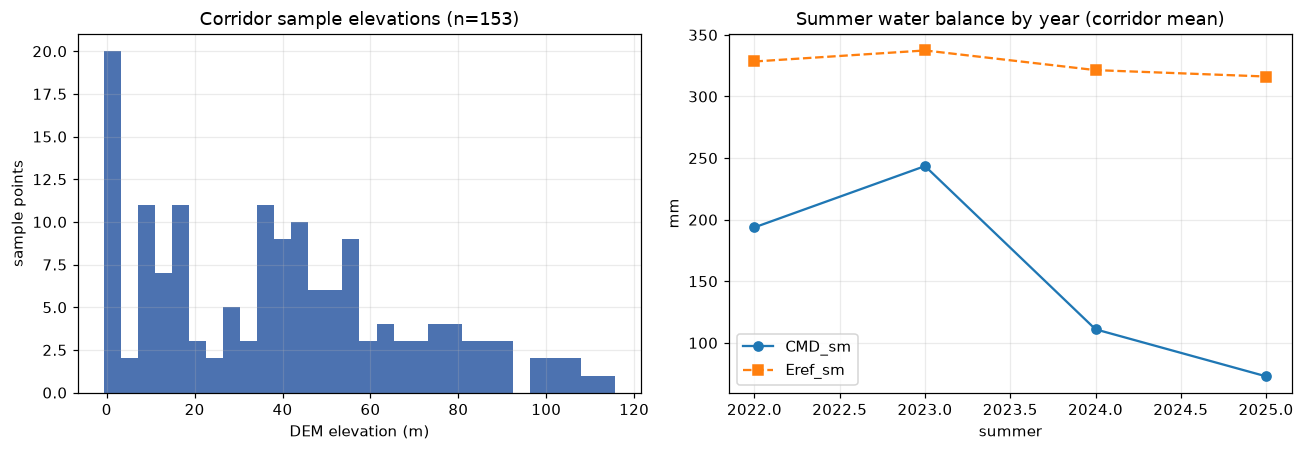

In [3]:
# Elevation is the lever the scale-free downscaling actually pulls.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(pts["elev_m"], bins=30, color="#4c72b0")
axes[0].set(xlabel="DEM elevation (m)", ylabel="sample points",
            title=f"Corridor sample elevations (n={len(pts)})")

yearly = climate[climate["year"].notna()]
if not yearly.empty:
    for var, style in (("CMD_sm", "-o"), ("Eref_sm", "--s")):
        if var in yearly:
            g = yearly.groupby("year")[var].mean()
            axes[1].plot(g.index.astype(int), g.values, style, label=var)
    axes[1].set(xlabel="summer", ylabel="mm",
                title="Summer water balance by year (corridor mean)")
    axes[1].legend()
plt.tight_layout(); plt.show()

## Stage 2 — Ground truth: a radiometric bug, and its correction

Phase 2 concluded that NDVI *saturates* — 87% of corridors above 0.9 — and used
that to justify moving the target to CDEI. **That conclusion was an artifact.**

Sentinel-2 baseline ≥ 04.00 stores a −1000 DN reflectance offset, and the Phase 2
code subtracted it unconditionally. Element84's `sentinel-2-l2a` products have
already had it removed, so subtracting again drove red reflectance negative,
where the `clip(min=0)` guard pinned it at zero and NDVI became *exactly* 1.0 for
69% of pixels.

The vendor flag turned out not to be trustworthy either: summer-2022 scenes
marked `boa_offset_applied: False` carry the same DN magnitudes as ones marked
`True`. So the offset is now **measured from each scene's dark pixels** (the
Fraser River and Boundary Bay reliably supply near-zero reflectance targets)
rather than declared, and applied per time step.

CDEI is still the right target — SWIR-based water content responds while a
canopy is still green — but the *empirical* argument for it does not survive the
fix, and Phase 2's numbers were recomputed.

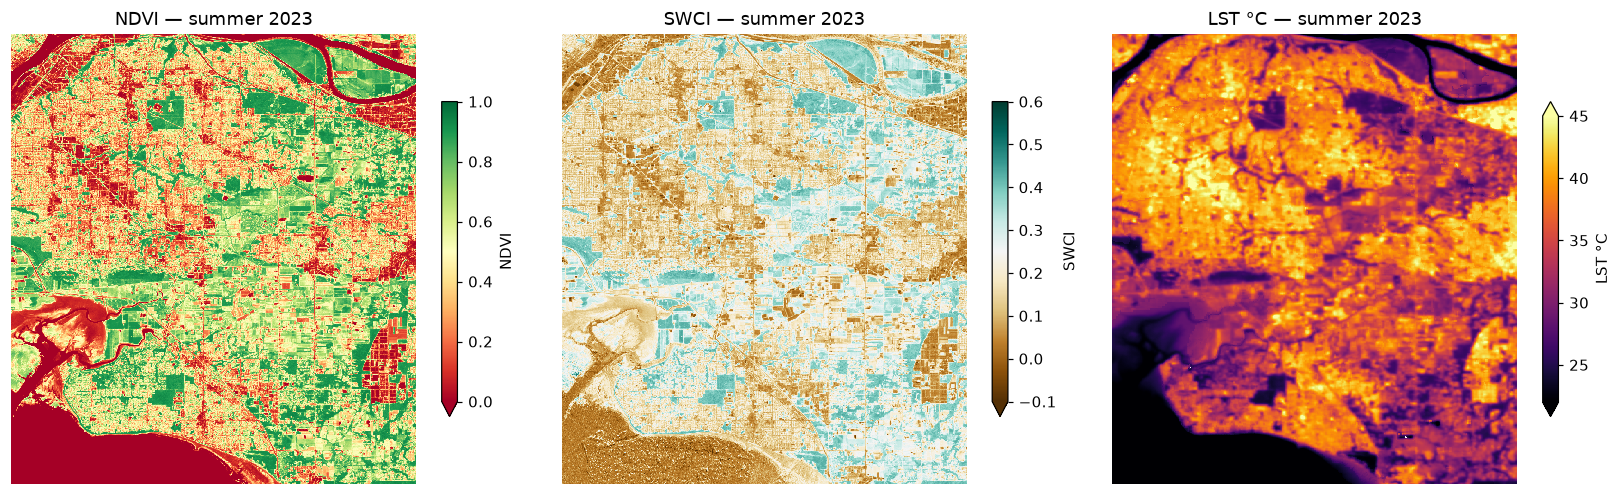

NDVI pixels exactly 1.000 : 0.0%  (pre-fix this was 69%)
NDVI median               : +0.463


In [4]:
opt = rioxarray.open_rasterio(INT / "optical_2023.tif", masked=True)
lst = rioxarray.open_rasterio(INT / "lst_2023.tif", masked=True).squeeze()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, da, name, cmap, rng in (
        (axes[0], opt[0], "NDVI",  "RdYlGn",   (0, 1)),
        (axes[1], opt[1], "SWCI",  "BrBG",     (-0.1, 0.6)),
        (axes[2], lst,    "LST °C", "inferno", (22, 45))):
    da.plot.imshow(ax=ax, cmap=cmap, vmin=rng[0], vmax=rng[1],
                   cbar_kwargs={"shrink": .7, "label": name})
    ax.set_title(f"{name} — summer 2023"); ax.set_axis_off()
plt.tight_layout(); plt.show()

ndvi_px = opt[0].values.ravel(); ndvi_px = ndvi_px[np.isfinite(ndvi_px)]
print(f"NDVI pixels exactly 1.000 : {float((ndvi_px >= 0.999).mean())*100:.1f}%  "
      f"(pre-fix this was 69%)")
print(f"NDVI median               : {np.median(ndvi_px):+.3f}")

## Stage 3 — The target: CDEI

$$\mathrm{CDEI} = \frac{d(\mathrm{SWCI}, \mathrm{NDVI})}{\mathrm{RLST}}$$

* **d** — perpendicular distance from a corridor's (NDVI, SWCI) position to the
  **dry edge**, the lower envelope of SWCI as a function of NDVI. Far above the
  edge = holds more water than the driest corridor of comparable greenness.
  The edge is fit **once across all corridor-summers**; a per-year edge would
  re-zero the index every summer and erase the between-year signal the
  experiment exists to predict.
* **RLST** — the corridor's summer LST over its *own* multi-summer mean, in
  **Kelvin**. A ratio is only meaningful on an absolute scale; the price is that
  the modulation is gentle by construction, which the plot below reports rather
  than hides.

Every band is aggregated to corridor polygons *first* (coverage-weighted, via
`exactextract`) and the index algebra happens on those corridor values — 20 m
Sentinel-2 and 30 m Landsat do not share a grid, and the analysis unit is the
polygon regardless.

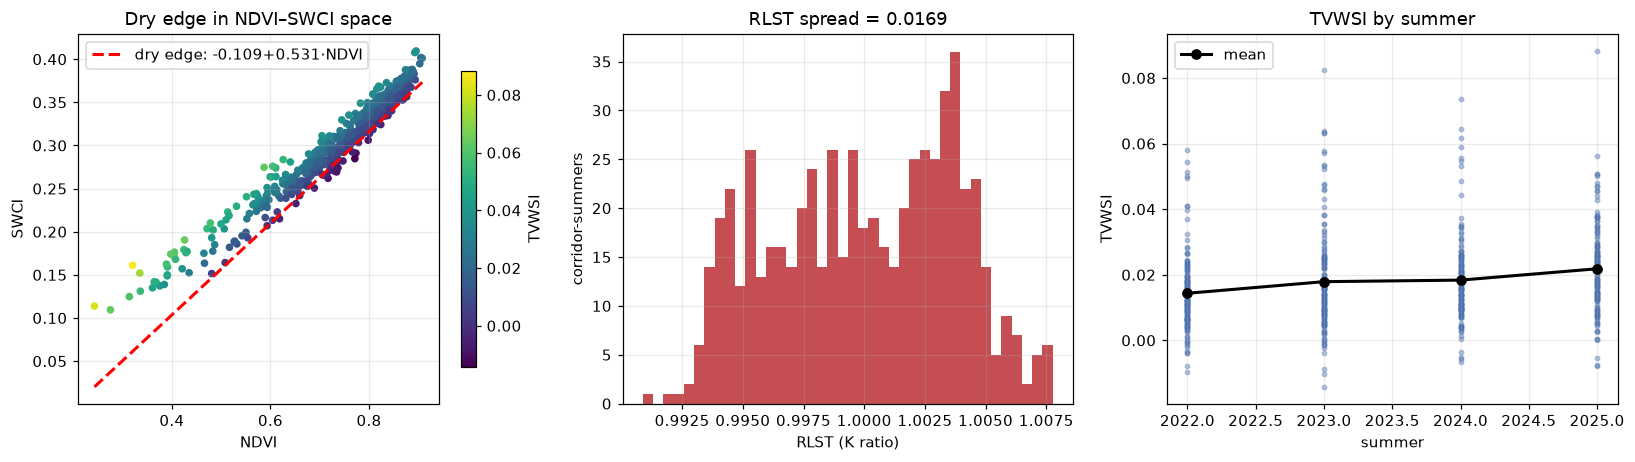

CDEI variability — between corridors sd=0.0126 | within corridor across summers sd=0.0053


In [5]:
from src.pipeline.assemble import zonal_year, compute_tvwsi

rs = pd.concat([zonal_year(INT / "corridors_analysis.gpkg", INT, y) for y in YEARS],
               ignore_index=True)
target = compute_tvwsi(rs)
a, b = target["dry_edge_a"].iloc[0], target["dry_edge_b"].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
sc = axes[0].scatter(target["ndvi_mean"], target["swci_mean"], c=target["tvwsi"],
                     cmap="viridis", s=16)
xs = np.linspace(target["ndvi_mean"].min(), target["ndvi_mean"].max(), 50)
axes[0].plot(xs, a + b * xs, "r--", lw=2, label=f"dry edge: {a:+.3f}{b:+.3f}·NDVI")
axes[0].set(xlabel="NDVI", ylabel="SWCI", title="Dry edge in NDVI–SWCI space")
axes[0].legend(); plt.colorbar(sc, ax=axes[0], label="CDEI", shrink=.8)

axes[1].hist(target["rlst"], bins=40, color="#c44e52")
axes[1].set(xlabel="RLST (K ratio)", ylabel="corridor-summers",
            title=f"RLST spread = {target['rlst'].max()-target['rlst'].min():.4f}")

for y, g in target.groupby("year"):
    axes[2].scatter([y]*len(g), g["tvwsi"], s=8, alpha=.4, color="#4c72b0")
axes[2].plot(sorted(target["year"].unique()),
             target.groupby("year")["tvwsi"].mean().values, "k-o", lw=2, label="mean")
axes[2].set(xlabel="summer", ylabel="CDEI", title="CDEI by summer"); axes[2].legend()
plt.tight_layout(); plt.show()

within = target.groupby("objectid")["tvwsi"].std().mean()
between = target.groupby("objectid")["tvwsi"].mean().std()
print(f"CDEI variability — between corridors sd={between:.4f} | "
      f"within corridor across summers sd={within:.4f}")

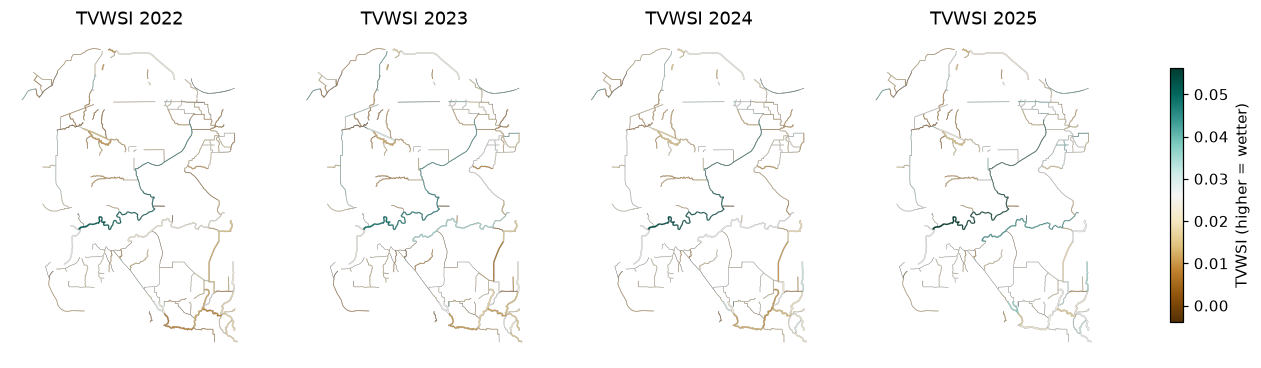

In [6]:
# Per-corridor CDEI map, one panel per summer.
corr = gpd.read_file(INT / "corridors_analysis.gpkg")[["objectid", "geometry"]]
tv = corr.merge(target[["objectid", "year", "tvwsi"]], on="objectid")
vmin, vmax = tv["tvwsi"].quantile([.02, .98])

fig, axes = plt.subplots(1, len(YEARS), figsize=(4 * len(YEARS), 5))
for ax, y in zip(np.atleast_1d(axes), YEARS):
    sub = tv[tv["year"] == y]
    sub.plot(ax=ax, column="tvwsi", cmap="BrBG", vmin=vmin, vmax=vmax,
             edgecolor="grey", linewidth=.15)
    ax.set_title(f"CDEI {y}"); ax.set_axis_off()
fig.colorbar(plt.cm.ScalarMappable(cmap="BrBG",
             norm=plt.Normalize(vmin, vmax)), ax=axes, shrink=.6,
             label="CDEI (higher = wetter)")
plt.show()

## Stage 4 — Assemble the ML table

One row per corridor × summer: the CDEI target joined to the climate
predictors, plus anomalies against the 1961–1990 normal and a Mahalanobis
**novelty** score measuring how far each corridor-summer sits from the
historical baseline cloud.

*(Normals note: the API serves only `Normal_1961_1990`; `Normal_1971_2000` and
`Normal_1991_2020` return `-9999` sentinels, so anomalies are taken against
1961–1990 — a documented deviation from the plan.)*

**Leakage discipline.** The A-vs-B test uses the
**climate-only** group. RLST is available as an `rs_augmented` variant but is
never mixed in: CDEI is itself remote-sensing derived, and an RS predictor
against an RS target would confound the resolution question. Elevation is
excluded for a related reason — it is a DEM *input* to ClimateBC, not a climate
variable, and handing it over would let Model A win on terrain.

In [7]:
from src.pipeline import assemble

feat_path = PROC / "features.parquet"
if REFETCH or not feat_path.exists():
    assemble.run(INT / "corridors_analysis.gpkg", INT, feat_path, years=YEARS)

feats = pd.read_parquet(feat_path)
groups = assemble.predictor_columns(feats)
print(f"{len(feats)} rows | {feats['objectid'].nunique()} corridors "
      f"x {feats['year'].nunique()} summers")
print(f"climate-only predictors ({len(groups['climate_only'])}): {groups['climate_only']}")
feats[["objectid", "year", "tvwsi", "novelty"] + groups["climate_only"][:4]].head()

612 rows | 153 corridors x 4 summers
climate-only predictors (14): ['CMD_sm', 'CMD_sm_anom', 'DD18_sm', 'Eref_sm', 'Eref_sm_anom', 'PPT_sm', 'PPT_sm_anom', 'Rad_sm', 'Tmax_sm', 'Tmax_sm_anom', 'Tmin_sm', 'Tmin_sm_anom', 'logPPT_sm', 'novelty']


,objectid,year,tvwsi,novelty,CMD_sm,CMD_sm_anom,DD18_sm,Eref_sm
0,1,2022,0.001414,1.061702,195.0,24.0,162.0,326.0
1,2,2022,0.016599,1.624016,191.0,24.0,159.0,321.0
2,3,2022,0.006644,1.297870,197.0,36.0,193.0,330.0
3,4,2022,0.016028,1.297870,199.0,36.0,196.0,331.0
4,5,2022,0.004082,1.354911,194.0,37.0,191.0,328.0


## Stage 5 — The core experiment: Model A vs Model B

* **Model A (scale-free)** — ClimateBC sampled at each corridor's own location
  and elevation.
* **Model B (coarse)** — *the same variables*, averaged within 4 km cells per
  year; each corridor then takes its cell's value. Averaging within (cell, year)
  leaves the temporal signal completely intact, so only spatial detail is
  destroyed.

**Validation.** Repeated spatially-blocked leave-one-block-out CV, where blocks
are KMeans clusters of corridor coordinates. Because blocking is done on the
*corridor*, every summer of a corridor lands in the same block — grouped and
spatially-blocked CV are the same operation here, so a corridor can never appear
in both train and test. Repeats re-seed the blocking so the result is not one
lucky partition.

**Read the upscaling diagnostic first.** If coarsening removes almost no spatial
variance, then A and B are nearly the same model and a null result is
*uninformative* rather than negative. That distinction has to be visible in the
output, not argued afterwards.

In [8]:
from src.pipeline import experiment as ex

res = ex.run(feat_path, kind="rf", cell_m=4000.0, n_blocks=5, n_repeats=5)
fa, fb = res["folds_a"], res["folds_b"]

print(f"folds: {len(fa)}  |  predictors: {len(res['features'])}")
print(f"Model A (scale-free): RMSE {fa.rmse.mean():.5f}  MAE {fa.mae.mean():.5f}  R2 {fa.r2.mean():+.3f}")
print(f"Model B (coarse 4km): RMSE {fb.rmse.mean():.5f}  MAE {fb.mae.mean():.5f}  R2 {fb.r2.mean():+.3f}")
res["upscaling"].head(10)

folds: 25  |  predictors: 14
Model A (scale-free): RMSE 0.01393  MAE 0.01057  R2 -0.042
Model B (coarse 4km): RMSE 0.01397  MAE 0.01039  R2 -0.051


,feature,spatial_var_fine,spatial_var_coarse,var_removed_frac
13,novelty,0.168477,0.101084,0.400011
11,Tmin_sm_anom,0.005703,0.004291,0.247550
3,Eref_sm,17.154940,13.551137,0.210074
9,Tmax_sm_anom,0.007089,0.005621,0.207062
8,Tmax_sm,0.088733,0.072380,0.184297
7,Rad_sm,0.006935,0.005818,0.161086
0,CMD_sm,95.414755,82.475226,0.135614
2,DD18_sm,225.172263,200.122127,0.111249
10,Tmin_sm,0.086571,0.077949,0.099591
4,Eref_sm_anom,2.361848,2.128807,0.098669


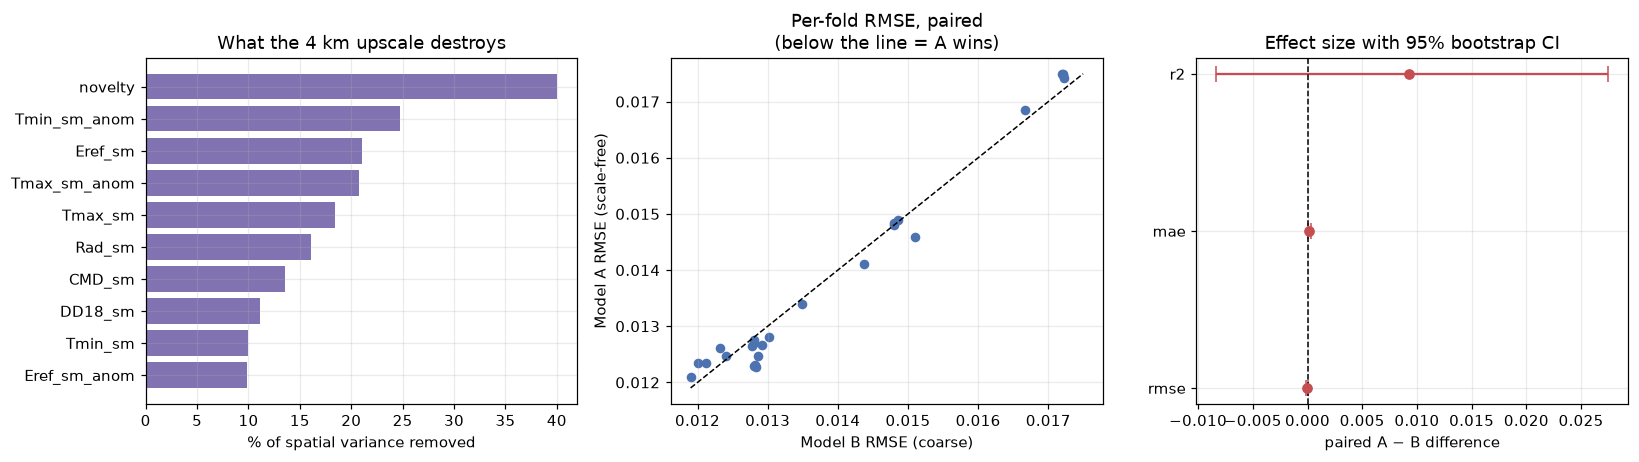

  rmse  A−B = -0.00004  95% CI [-0.00016, +0.00007]  | A better in 48% of folds
  mae   A−B = +0.00018  95% CI [+0.00002, +0.00033]  | A better in 28% of folds
  r2    A−B = +0.00925  95% CI [-0.00837, +0.02749]  | A better in 48% of folds


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

u = res["upscaling"].head(10)[::-1]
axes[0].barh(u["feature"], u["var_removed_frac"] * 100, color="#8172b2")
axes[0].set(xlabel="% of spatial variance removed",
            title="What the 4 km upscale destroys")

paired = fa[["repeat", "block", "rmse"]].merge(
    fb[["repeat", "block", "rmse"]], on=["repeat", "block"], suffixes=("_a", "_b"))
lim = [min(paired.rmse_a.min(), paired.rmse_b.min()),
       max(paired.rmse_a.max(), paired.rmse_b.max())]
axes[1].scatter(paired.rmse_b, paired.rmse_a, s=28, color="#4c72b0")
axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set(xlabel="Model B RMSE (coarse)", ylabel="Model A RMSE (scale-free)",
            title="Per-fold RMSE, paired\n(below the line = A wins)")

for i, (m, d) in enumerate(res["diffs"].items()):
    axes[2].errorbar(d["mean_diff"], i,
                     xerr=[[d["mean_diff"] - d["ci_lo"]], [d["ci_hi"] - d["mean_diff"]]],
                     fmt="o", capsize=5, color="#c44e52")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].set_yticks(range(len(res["diffs"])));
axes[2].set_yticklabels(list(res["diffs"]))
axes[2].set(xlabel="paired A − B difference", title="Effect size with 95% bootstrap CI")
plt.tight_layout(); plt.show()

for m, d in res["diffs"].items():
    print(f"  {m:<5} A−B = {d['mean_diff']:+.5f}  95% CI [{d['ci_lo']:+.5f}, {d['ci_hi']:+.5f}]"
          f"  | A better in {d['frac_folds_a_better']*100:.0f}% of folds")

## Stage 6 — Forward temporal holdout, importance, and novelty strata

The temporal holdout is strictly harder than spatial CV: train on the earlier
summers, predict the most recent one, so the model cannot lean on a memorized
year effect. Corridors do repeat across that split by design — it tests temporal
transfer, and the spatial CV tests transfer to unseen *places*.

Novelty stratification is where extrapolation risk shows up: high-novelty
corridors are the ones whose climate sits furthest from the historical baseline,
and therefore the ones whose confident-looking predictions deserve least trust.

forward holdout — train < 2025, test 2025 (n=153)
  A: RMSE 0.01371  R2 -0.041
  B: RMSE 0.01365  R2 -0.032


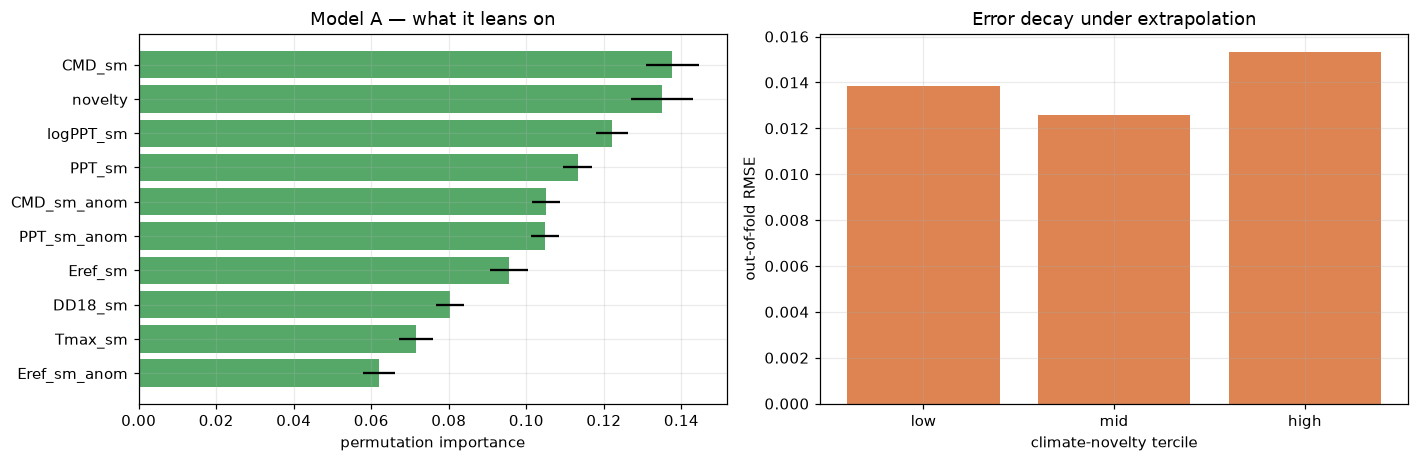

,stratum,level,n,rmse,mae,r2
0,novelty,low,204,0.013853,0.010194,-0.038380
1,novelty,mid,204,0.012592,0.009607,-0.063885
2,novelty,high,204,0.015337,0.011607,-0.106007
3,ecological_value,High,180,0.011949,0.008990,-0.070986
4,ecological_value,Low,104,0.018350,0.014377,-0.003756
5,ecological_value,Moderate,316,0.012061,0.009600,-0.069464


In [10]:
ta, tb = res["temporal_a"], res["temporal_b"]
if ta.get("n_test"):
    print(f"forward holdout — train < {ta['test_year']}, test {ta['test_year']} (n={ta['n_test']})")
    print(f"  A: RMSE {ta['rmse']:.5f}  R2 {ta['r2']:+.3f}")
    print(f"  B: RMSE {tb['rmse']:.5f}  R2 {tb['r2']:+.3f}")
else:
    print("forward holdout unavailable: the panel spans a single summer")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
imp = res["importance"].head(10)[::-1]
axes[0].barh(imp["feature"], imp["importance"], xerr=imp["sd"], color="#55a868")
axes[0].set(xlabel="permutation importance", title="Model A — what it leans on")

st = res["strata"]
nov = st[st["stratum"] == "novelty"]
if not nov.empty:
    axes[1].bar(nov["level"], nov["rmse"], color="#dd8452")
    axes[1].set(xlabel="climate-novelty tercile", ylabel="out-of-fold RMSE",
                title="Error decay under extrapolation")
plt.tight_layout(); plt.show()
st

## Verdict

Applying the pre-registered falsification rule to the paired differences.

In [11]:
print("=" * 74)
print(f"HYPOTHESIS: {res['verdict']}")
print("=" * 74)
print(res["verdict_reason"])
print()
d = res["diffs"]["rmse"]
print(f"paired RMSE difference (A − B): {d['mean_diff']:+.5f}  "
      f"95% CI [{d['ci_lo']:+.5f}, {d['ci_hi']:+.5f}] over {d['n_folds']} folds")
print(f"median spatial variance removed by the upscale: "
      f"{res['upscaling']['var_removed_frac'].median()*100:.1f}%")
print(f"panel: {feats['objectid'].nunique()} corridors x {feats['year'].nunique()} summers "
      f"= {len(feats)} rows")

HYPOTHESIS: INCONCLUSIVE
The test cannot discriminate, for two independent reasons. Neither model has predictive skill (best CV R2 = -0.042, at or below the no-skill line), so the comparison is between two failures. And the coarse upscale removed only 12% of the predictors' spatial variance, so Models A and B are nearly the same model. This is NOT evidence against downscaling — it is the experiment reporting that, as specified, it has nothing to measure.

paired RMSE difference (A − B): -0.00004  95% CI [-0.00016, +0.00007] over 25 folds
median spatial variance removed by the upscale: 12.3%
panel: 153 corridors x 4 summers = 612 rows


### Sensitivity checks

The plan asks for two: the coarse cell size (4 km default, and a coarser
alternative), and running with vs without low-coverage corridors. Both re-run the
identical pipeline with one knob moved.

In [12]:
sens = []
for cell in (4000.0, 12000.0):
    r = ex.run(feat_path, kind="rf", cell_m=cell, n_blocks=5, n_repeats=3)
    sens.append({"variant": f"cell {cell/1000:.0f} km", "verdict": r["verdict"],
                 "A_rmse": r["folds_a"].rmse.mean(), "B_rmse": r["folds_b"].rmse.mean(),
                 "diff": r["diffs"]["rmse"]["mean_diff"],
                 "ci_lo": r["diffs"]["rmse"]["ci_lo"], "ci_hi": r["diffs"]["rmse"]["ci_hi"]})

r = ex.run(feat_path, kind="gb", cell_m=4000.0, n_blocks=5, n_repeats=3)
sens.append({"variant": "gradient boosting", "verdict": r["verdict"],
             "A_rmse": r["folds_a"].rmse.mean(), "B_rmse": r["folds_b"].rmse.mean(),
             "diff": r["diffs"]["rmse"]["mean_diff"],
             "ci_lo": r["diffs"]["rmse"]["ci_lo"], "ci_hi": r["diffs"]["rmse"]["ci_hi"]})

pd.DataFrame(sens).round(5)

,variant,verdict,A_rmse,B_rmse,diff,ci_lo,ci_hi
0,cell 4 km,INCONCLUSIVE,0.01393,0.01403,-0.00009,-0.00025,0.00006
1,cell 12 km,INCONCLUSIVE,0.01393,0.01388,0.00005,-0.00015,0.00027
2,gradient boosting,INCONCLUSIVE,0.01548,0.01529,0.00019,-0.00020,0.00059
